In [1]:
import os
os.chdir("/rds/rds-clecat/generative_modelling/cross_debug_2/tests/certification_notebooks/2D_FFT_Torch")

In [2]:
# import useful libraries
import numpy as np
import matplotlib.pyplot as plt

import os
import sys

# add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.dirname(os.path.abspath(os.getcwd() + "../../../"))
sys.path.append(PARENT_DIR)
print("Parent directory added to sys.path:", ".../" + PARENT_DIR.split("/")[-1])

# test data directory
DATA_TEST_PATH = PARENT_DIR + "/data" + "/test"
print("Dataset dirctory used:", ".../" + PARENT_DIR.split("/")[-1] + DATA_TEST_PATH.split(PARENT_DIR.split("/")[-1])[-1])

from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch
DataClass = STL_2D_Kernel_Torch
from STL_main.Synthesis import optimize_scattering_LBFGS
from STL_main.torch_backend import _DEFAULT_DEVICE
from STL_main.Synthesis import synthesize_from_maps
print("Working on device:", _DEFAULT_DEVICE)


import torch

Parent directory added to sys.path: .../cross_debug_2
Dataset dirctory used: .../cross_debug_2/data/test
Working on device: cuda


In [3]:
def plot_target_vs_synthesis(target, synthesis, suptitle, titles=["Target", "Synthesis"]):
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

    t = target.cpu().numpy()
    u = synthesis.cpu().numpy()

    # Color scale limits of the target image, ignoring NaNs
    mean_t = np.nanmean(t)
    std_t = np.nanstd(t)

    vmin = mean_t - 3 * std_t
    vmax = mean_t + 3 * std_t

    im0 = axes[0].imshow(t, cmap="plasma", vmin=vmin, vmax=vmax)
    axes[0].axis("off")
    axes[0].set_title(titles[0])

    im1 = axes[1].imshow(u, cmap="plasma", vmin=vmin, vmax=vmax)
    axes[1].axis("off")
    axes[1].set_title(titles[1])

    fig.colorbar(im0, ax=axes, shrink=0.7)

    fig.suptitle(suptitle, fontsize=16)

    plt.show()
    

# Try to isolate the bug : check the paths

In [12]:
import os
print(os.getcwd())

/rds/rds-clecat/generative_modelling/cross_debug_2/tests/certification_notebooks/2D_FFT_Torch


In [13]:
from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch
print(STL_2D_Kernel_Torch.__module__)

STL_main.STL_2D_Kernel_Torch


In [14]:
import inspect
from STL_main.STL_2D_Kernel_Torch import STL_2D_Kernel_Torch

print(inspect.getfile(STL_2D_Kernel_Torch))

/rds/rds-clecat/generative_modelling/cross_debug_2/STL_main/STL_2D_Kernel_Torch.py


In [15]:
import inspect
from STL_main.Synthesis import synthesize_from_maps

print(inspect.getfile(synthesize_from_maps))

/rds/rds-clecat/generative_modelling/cross_debug_2/STL_main/Synthesis.py


# pbc = True, CIB map, works well

In [8]:
patch = np.load("/rds/rds-clecat/generative_modelling/CIB_run1_first10/patch_000000.npy").astype(np.float64)


data_target = STL_2D_Kernel_Torch(
    patch,
    pbc=True  
)

u_syn = synthesize_from_maps(
    data_target,
    pbc_running=True,   
    nbatch=1,
    compute_PS=True     
)

Running synthesis on device : cuda:0 dtype : torch.float64
Initial shape for u: (1, 1, 512, 512)
Synthesis on 5914 ST coefficients
[LBFGS] inner iter 10, loss = 8.672539e+01
[LBFGS] inner iter 20, loss = 2.818895e+00
[LBFGS] inner iter 30, loss = 1.056355e+00
[LBFGS] inner iter 40, loss = 5.529686e-01
[LBFGS] inner iter 50, loss = 3.522496e-01
[LBFGS] inner iter 60, loss = 2.749012e-01
[LBFGS] inner iter 70, loss = 2.286424e-01
[LBFGS] inner iter 80, loss = 1.912796e-01
[LBFGS] inner iter 90, loss = 1.718090e-01
[LBFGS] inner iter 100, loss = 1.548121e-01
[LBFGS] inner iter 110, loss = 1.439997e-01
[LBFGS] inner iter 120, loss = 1.364923e-01
[LBFGS] inner iter 130, loss = 1.299313e-01
[LBFGS] inner iter 140, loss = 1.255370e-01
[LBFGS] inner iter 150, loss = 1.218372e-01
[LBFGS] inner iter 160, loss = 1.177199e-01
[LBFGS] inner iter 170, loss = 1.154790e-01
[LBFGS] inner iter 180, loss = 1.129133e-01
[LBFGS] inner iter 190, loss = 1.104507e-01
[LBFGS] inner iter 200, loss = 1.080396e-0

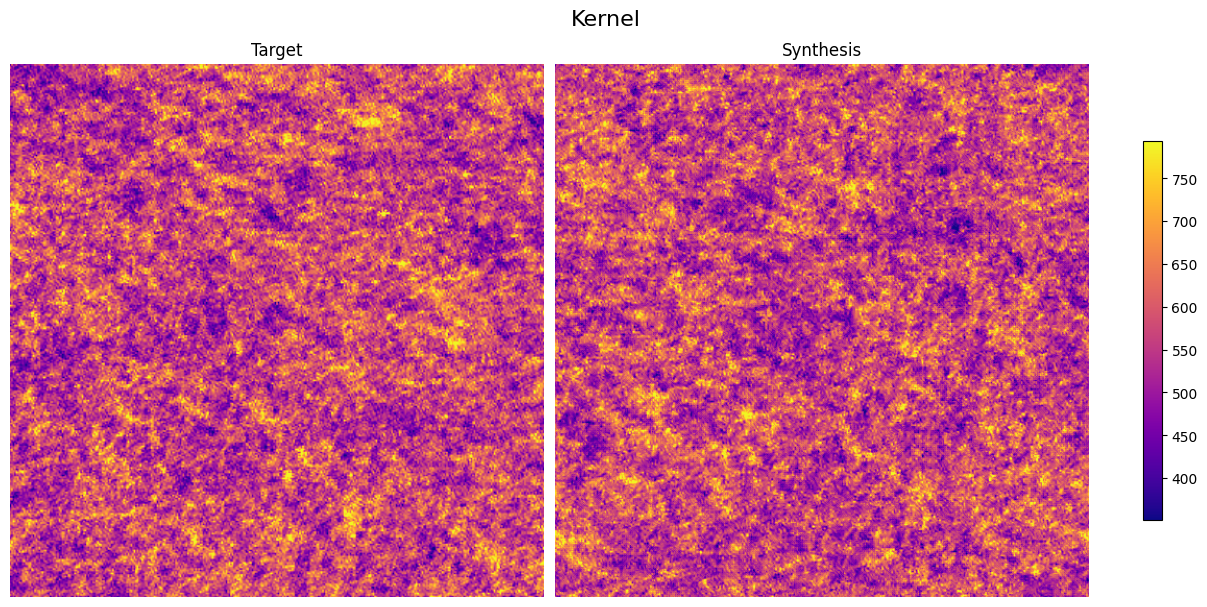

In [19]:
plot_target_vs_synthesis(data_target.array, u_syn, suptitle = "Pbc = True", titles=["Target", "Synthesis"])

# pbc = False, CIB map, doesn't work

In [9]:
patch = np.load("/rds/rds-clecat/generative_modelling/CIB_run1_first10/patch_000000.npy").astype(np.float64)


data_target = STL_2D_Kernel_Torch(
    patch,
    pbc=False  
)

u_syn = synthesize_from_maps(
    data_target,
    pbc_running=True,   
    nbatch=1,
    compute_PS=True     
)

Running synthesis on device : cuda:0 dtype : torch.float64
Initial shape for u: (1, 1, 512, 512)
Synthesis on 4002 ST coefficients
[LBFGS] inner iter 10, loss = 1.377057e+01
[LBFGS] inner iter 20, loss = 2.712021e+00
[LBFGS] inner iter 30, loss = 1.998635e+00
[LBFGS] inner iter 40, loss = 1.860512e+00
[LBFGS] inner iter 50, loss = 1.807631e+00
[LBFGS] inner iter 60, loss = 1.761612e+00
[LBFGS] inner iter 70, loss = 1.733858e+00
[LBFGS] inner iter 80, loss = 1.715311e+00
[LBFGS] inner iter 90, loss = 1.700769e+00
[LBFGS] inner iter 100, loss = 1.690796e+00
[LBFGS] inner iter 110, loss = 1.682273e+00
[LBFGS] inner iter 120, loss = 1.675171e+00
[LBFGS] inner iter 130, loss = 1.669940e+00
[LBFGS] inner iter 140, loss = 1.665576e+00
[LBFGS] inner iter 150, loss = 1.662640e+00
[LBFGS] inner iter 160, loss = 1.659826e+00
[LBFGS] inner iter 170, loss = 1.656548e+00
[LBFGS] inner iter 180, loss = 1.653969e+00
[LBFGS] inner iter 190, loss = 1.651950e+00
[LBFGS] inner iter 200, loss = 1.649725e+0

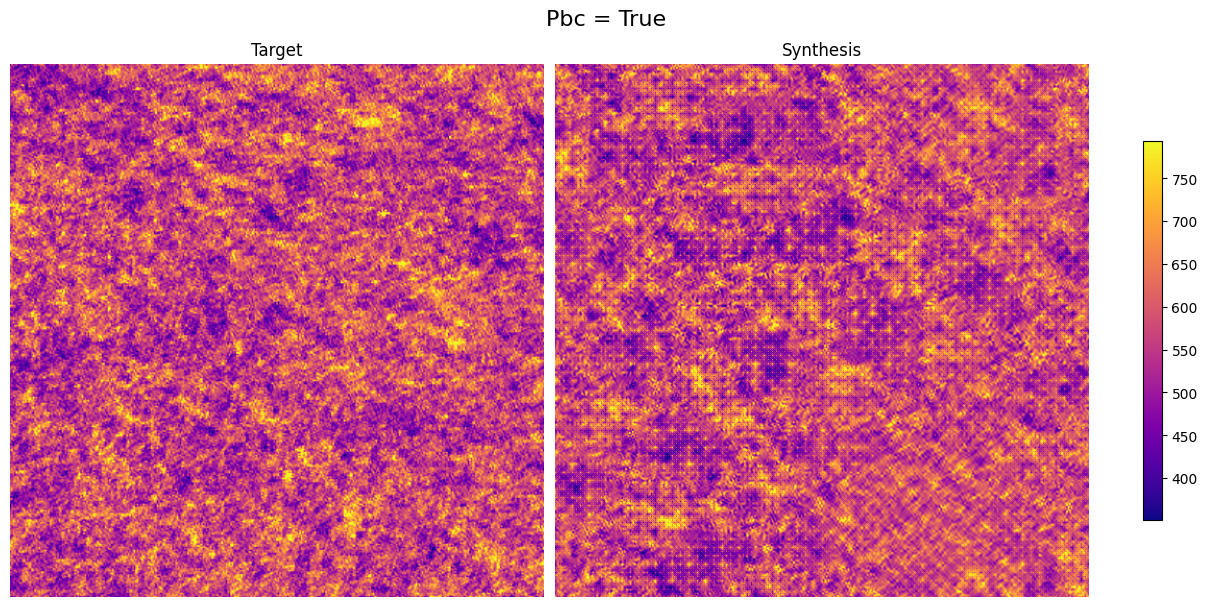

In [28]:
plot_target_vs_synthesis(data_target.array, u_syn, suptitle = "Pbc = True", titles=["Target", "Synthesis"])

# Same test on the certification image

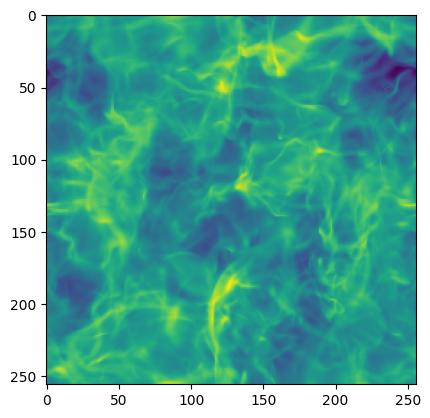

In [16]:
im = np.load(DATA_TEST_PATH + "/" + 'Turb_6.npy')[:,None,:,:]
data = DataClass(im[0,0], pbc=True)
plt.imshow(data.array.cpu().numpy())

# Certification patch, pbc = False, works well

In [19]:
im_target = im[0, 0, :, :] # Mono channel image

# Instantiate kernel data class on the target image
data_target_kernel = STL_2D_Kernel_Torch(im_target, pbc=False)

# Call user-friendly synthesis wrapper
u_kernel = synthesize_from_maps(
    data_target_kernel,
    pbc_running=True,
    nbatch=1,
    compute_PS = True
)

Running synthesis on device : cuda:0 dtype : torch.float64
Initial shape for u: (1, 1, 256, 256)
Synthesis on 2538 ST coefficients
[LBFGS] inner iter 10, loss = 8.142858e+03
[LBFGS] inner iter 20, loss = 3.226009e+01
[LBFGS] inner iter 30, loss = 6.391390e+00
[LBFGS] inner iter 40, loss = 1.805319e+00
[LBFGS] inner iter 50, loss = 9.866524e-01
[LBFGS] inner iter 60, loss = 6.717288e-01
[LBFGS] inner iter 70, loss = 5.051391e-01
[LBFGS] inner iter 80, loss = 4.097780e-01
[LBFGS] inner iter 90, loss = 3.618653e-01
[LBFGS] inner iter 100, loss = 3.148552e-01
[LBFGS] inner iter 110, loss = 2.784024e-01
[LBFGS] inner iter 120, loss = 2.500864e-01
[LBFGS] inner iter 130, loss = 2.216809e-01
[LBFGS] inner iter 140, loss = 1.973678e-01
[LBFGS] inner iter 150, loss = 1.794011e-01
[LBFGS] inner iter 160, loss = 1.661780e-01
[LBFGS] inner iter 170, loss = 1.502587e-01
[LBFGS] inner iter 180, loss = 1.400825e-01
[LBFGS] inner iter 190, loss = 1.288516e-01
[LBFGS] inner iter 200, loss = 1.201829e-0

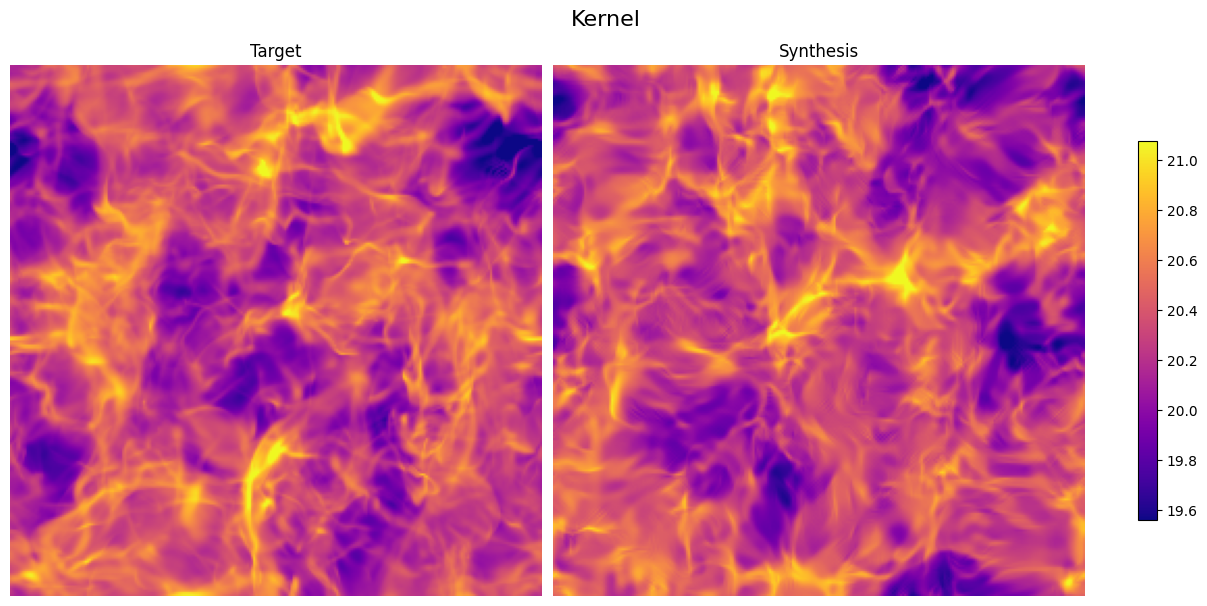

In [17]:
plot_target_vs_synthesis(data_target_kernel.array, u_kernel, suptitle = "Kernel", titles=["Target", "Synthesis"])

# Certification patch, pbc = True, works well

In [22]:
im_target = im[0, 0, :, :] # Mono channel image

# Instantiate kernel data class on the target image
data_target_kernel = STL_2D_Kernel_Torch(im_target, pbc=True)

# Call user-friendly synthesis wrapper
u_kernel = synthesize_from_maps(
    data_target_kernel,
    pbc_running=True,
    nbatch=1,
    compute_PS = True
)

Running synthesis on device : cuda:0 dtype : torch.float64
Initial shape for u: (1, 1, 256, 256)
Synthesis on 3986 ST coefficients
[LBFGS] inner iter 10, loss = 8.122747e+03
[LBFGS] inner iter 20, loss = 4.541935e+01
[LBFGS] inner iter 30, loss = 7.262993e+00
[LBFGS] inner iter 40, loss = 2.479115e+00
[LBFGS] inner iter 50, loss = 1.421640e+00
[LBFGS] inner iter 60, loss = 8.596038e-01
[LBFGS] inner iter 70, loss = 6.301467e-01
[LBFGS] inner iter 80, loss = 4.808020e-01
[LBFGS] inner iter 90, loss = 3.928086e-01
[LBFGS] inner iter 100, loss = 3.380753e-01
[LBFGS] inner iter 110, loss = 2.975214e-01
[LBFGS] inner iter 120, loss = 2.701019e-01
[LBFGS] inner iter 130, loss = 2.455172e-01
[LBFGS] inner iter 140, loss = 2.286995e-01
[LBFGS] inner iter 150, loss = 2.154786e-01
[LBFGS] inner iter 160, loss = 2.051276e-01
[LBFGS] inner iter 170, loss = 1.964316e-01
[LBFGS] inner iter 180, loss = 1.878855e-01
[LBFGS] inner iter 190, loss = 1.802478e-01
[LBFGS] inner iter 200, loss = 1.753406e-0

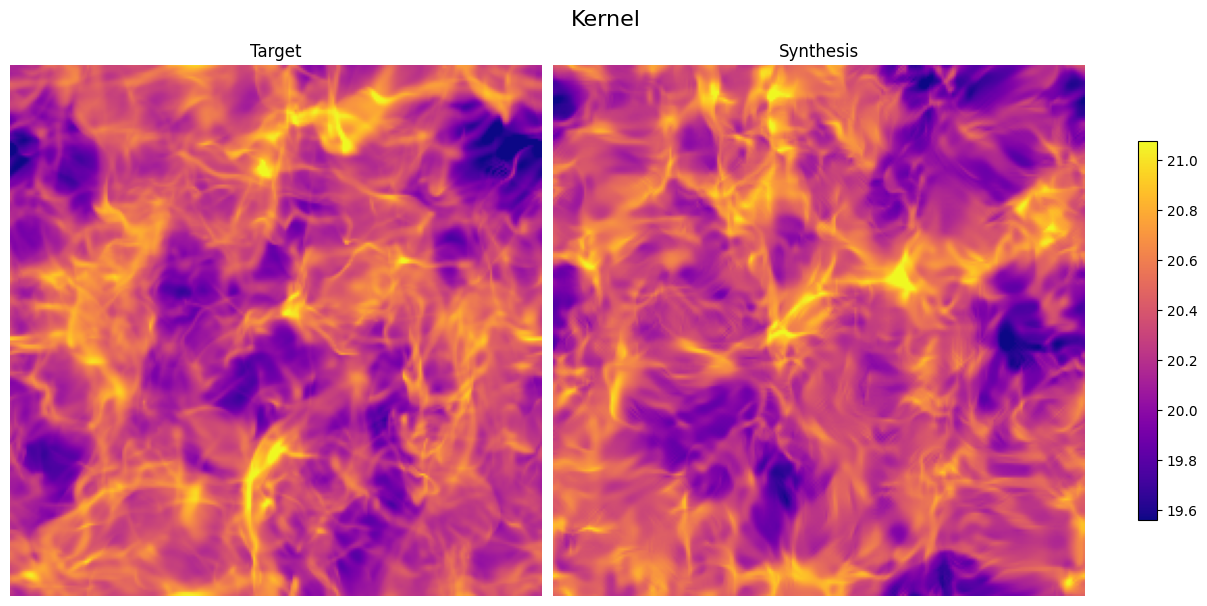

In [23]:
plot_target_vs_synthesis(data_target_kernel.array, u_kernel, suptitle = "Kernel", titles=["Target", "Synthesis"])